# Financial Health Scoring Engine

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from analytics.db import run_query

# Functions

In [28]:
def extract_percentage(value):
    if pd.isnull(value):
        return None
    
    try:
        return float(
            str(value)
            .split(":")[-1]
            .replace("%", "")
            .strip()
        )
    except:
        return None
    
def health_label(score):

    if score >= 85:
        return "EXCELLENT"

    elif score >= 70:
        return "GOOD"

    elif score >= 50:
        return "AVERAGE"

    elif score >= 35:
        return "WEAK"

    else:
        return "POOR"

In [5]:
fact_analysis = run_query("""
SELECT *
FROM fact_analysis
""")

fact_balance_sheet = run_query("""
SELECT *
FROM fact_balance_sheet
""")

fact_cash_flow = run_query("""
SELECT *
FROM fact_cash_flow
""")

fact_profit_loss = run_query("""
SELECT *
FROM fact_profit_loss
""")

In [6]:
fact_analysis.head()    

,id,company_id,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe
0,1,HDFCBANK,10 Years: 21%,10 Years: 22%,10 Years: 15%,10 Years: 17%
1,10,SBILIFE,5 Years: 24%,5 Years: 6%,5 Years: 8%,5 Years 14%
2,11,SBILIFE,3 Years: 17%,3 Years: 9%,3 Years: 7%,3 Years: 13%
3,12,SBILIFE,TTM: 43%,TTM: 18%,1 Year: -2%,Last Year: 12%
4,13,TCS,10 Years: 11%,10 Years: 9%,10 Years: 14%,10 Years: 40%


In [7]:
fact_balance_sheet.head()

,id,company_id,year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_asset,total_assets,fiscal_year,sorting_order,debt_to_equity,equity_ratio
0,136,ABB,Dec 2012,21.0,626.0,0.0,260.0,907.0,109.0,1.0,0.0,798.0,907.0,2012,2012,0.0,0.713341
1,137,ABB,Mar 2014,21.0,767.0,0.0,351.0,1139.0,98.0,1.0,0.0,1040.0,1139.0,2014,2014,0.0,0.691835
2,138,ABB,Mar 2015,21.0,916.0,0.0,436.0,1374.0,96.0,4.0,0.0,1274.0,1374.0,2015,2015,0.0,0.681951
3,139,ABB,Mar 2016,21.0,1174.0,0.0,421.0,1616.0,108.0,3.0,0.0,1505.0,1616.0,2016,2016,0.0,0.739480
4,140,ABB,Mar 2017,21.0,1366.0,0.0,679.0,2066.0,110.0,6.0,0.0,1950.0,2066.0,2017,2017,0.0,0.671346


In [8]:
fact_cash_flow.head()

,id,company_id,year,operating_activity,investing_activity,financing_activity,net_cash_flow,fiscal_year,sorting_order,free_cash_flow
0,37,TCS,Mar 2013,11615.0,-6038.0,-5729.0,-152.0,2013,2013,5577.0
1,38,TCS,Mar 2014,14751.0,-9452.0,-5673.0,-374.0,2014,2014,5299.0
2,39,TCS,Mar 2015,19369.0,-1807.0,-17168.0,394.0,2015,2015,17562.0
3,40,TCS,Mar 2016,19109.0,-5010.0,-9666.0,4433.0,2016,2016,14099.0
4,41,TCS,Mar 2017,25223.0,-16895.0,-11026.0,-2698.0,2017,2017,8328.0


In [9]:
fact_profit_loss.head()

,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,fiscal_year,sorting_order,net_profit_margin_pct,expense_ratio_pct,interest_coverage
0,73,ABB,TTM,6066.0,4519.0,1547.0,26.0,265.0,11.0,72.0,1728.0,NaN,1285.0,605.0,NaN,NaN,9999,21.183647,74.497197,140.636364
1,97,ADANIENSOL,TTM,22099.0,15507.0,6592.0,NaN,-844.0,3183.0,1912.0,653.0,NaN,589.0,6.0,NaN,NaN,9999,2.665279,70.170596,2.071002
2,110,ADANIENT,TTM,102311.0,88418.0,13893.0,14.0,1489.0,4150.0,3541.0,7691.0,NaN,6086.0,49.0,NaN,NaN,9999,5.948529,86.420815,3.347711
3,119,ADANIGREEN,TTM,10782.0,2682.0,8100.0,75.0,891.0,4959.0,2323.0,1709.0,NaN,1928.0,9.0,0.0,NaN,9999,17.881655,24.874791,1.633394
4,132,ADANIPORTS,TTM,28443.0,11278.0,17165.0,60.0,1039.0,2591.0,4053.0,11560.0,NaN,9743.0,45.0,NaN,NaN,9999,34.254474,39.651232,6.624855


## Latest Profit Data

In [15]:
latest_profit = fact_profit_loss.sort_values(
    "sorting_order",
    ascending=False
).groupby("company_id").first().reset_index()

latest_profit.head()

,company_id,id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,fiscal_year,sorting_order,net_profit_margin_pct,expense_ratio_pct,interest_coverage
0,ABB,73,TTM,6066.0,4519.0,1547.0,26.0,265.0,11.0,72.0,1728.0,26.0,1285.0,605.0,73.0,2024.0,9999,21.183647,74.497197,140.636364
1,ADANIENSOL,97,TTM,22099.0,15507.0,6592.0,30.0,-844.0,3183.0,1912.0,653.0,33.0,589.0,6.0,0.0,2024.0,9999,2.665279,70.170596,2.071002
2,ADANIENT,110,TTM,102311.0,88418.0,13893.0,14.0,1489.0,4150.0,3541.0,7691.0,33.0,6086.0,49.0,5.0,2024.0,9999,5.948529,86.420815,3.347711
3,ADANIGREEN,119,TTM,10782.0,2682.0,8100.0,75.0,891.0,4959.0,2323.0,1709.0,25.0,1928.0,9.0,0.0,2024.0,9999,17.881655,24.874791,1.633394
4,ADANIPORTS,145,TTM,28443.0,11278.0,17165.0,60.0,1039.0,2591.0,4053.0,11560.0,16.0,9743.0,45.0,16.0,2024.0,9999,34.254474,39.651232,6.624855


## Latest Balance Sheet

In [16]:
latest_balance = fact_balance_sheet.sort_values(
    "sorting_order",
    ascending=False
).groupby("company_id").first().reset_index()

latest_balance.head()

,company_id,id,year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_asset,total_assets,fiscal_year,sorting_order,debt_to_equity,equity_ratio
0,ABB,148,Sep 2024,21.0,3500.0,60.0,1481.0,5063.0,216.0,13.0,0.0,4834.0,5063.0,2024,2024,0.017041,0.695437
1,ADANIENSOL,160,Sep 2024,1201.0,19784.0,39009.0,9113.0,69107.0,38186.0,4355.0,1608.0,24958.0,69107.0,2024,2024,1.858899,0.303660
2,ADANIENT,182,Sep 2024,114.0,41782.0,80427.0,59445.0,181768.0,84751.0,29745.0,10322.0,56949.0,181768.0,2024,2024,1.919682,0.230492
3,ADANIGREEN,200,Sep 2024,1584.0,8992.0,67430.0,20252.0,98258.0,64632.0,14617.0,2331.0,16678.0,98258.0,2024,2024,6.375756,0.107635
4,ADANIPORTS,213,Sep 2024,432.0,56744.0,50485.0,18354.0,126015.0,79136.0,13328.0,4489.0,29062.0,126015.0,2024,2024,0.882975,0.453724


## Latest Cash Flow

In [17]:
latest_cashflow = fact_cash_flow.sort_values(
    "sorting_order",
    ascending=False
).groupby("company_id").first().reset_index()

latest_cashflow.head()

,company_id,id,year,operating_activity,investing_activity,financing_activity,net_cash_flow,fiscal_year,sorting_order,free_cash_flow
0,ABB,83,Mar 2024,6038.0,-4943.0,-543.0,551.0,2024,2024,1095.0
1,ADANIENSOL,94,Mar 2024,6038.0,-4943.0,-543.0,551.0,2024,2024,1095.0
2,ADANIENT,106,Mar 2024,10312.0,-18767.0,8879.0,424.0,2024,2024,-8455.0
3,ADANIGREEN,114,Mar 2024,7713.0,-21060.0,13953.0,606.0,2024,2024,-13347.0
4,ADANIPORTS,126,Mar 2024,15018.0,-6768.0,-7800.0,450.0,2024,2024,8250.0


### CLeaning

In [19]:
fact_analysis["sales_growth_pct"] = fact_analysis["compounded_sales_growth"].apply(extract_percentage)

fact_analysis["profit_growth_pct"] = fact_analysis["compounded_profit_growth"].apply(extract_percentage)

fact_analysis["stock_cagr_pct"] = fact_analysis["stock_price_cagr"].apply(extract_percentage)

fact_analysis["roe_pct"] = fact_analysis["roe"].apply(extract_percentage)

## Latest Analysis Data

In [20]:
latest_analysis = fact_analysis.groupby(
    "company_id"
).first().reset_index()

latest_analysis.head()

,company_id,id,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe,sales_growth_pct,profit_growth_pct,stock_cagr_pct,roe_pct
0,HDFCBANK,1,10 Years: 21%,10 Years: 22%,10 Years: 15%,10 Years: 17%,21.0,22.0,15.0,17.0
1,INFY,5,10 Years: 12%,10 Years: 9%,10 Years: 15%,10 Years: 27%,12.0,9.0,15.0,27.0
2,SBILIFE,10,5 Years: 24%,5 Years: 6%,5 Years: 8%,5 Years 14%,24.0,6.0,8.0,13.0
3,TCS,13,10 Years: 11%,10 Years: 9%,10 Years: 14%,10 Years: 40%,11.0,9.0,14.0,40.0
4,WIPRO,17,10 Years: 8%,10 Years: 3%,10 Years: 12%,10 Years: 18%,8.0,3.0,12.0,18.0


## Master Data Set - Merging

In [21]:
master_df = latest_profit.merge(
    latest_balance,
    on="company_id",
    how="left"
)

master_df = master_df.merge(
    latest_cashflow,
    on="company_id",
    how="left"
)

master_df = master_df.merge(
    latest_analysis[
        [
            "company_id",
            "sales_growth_pct",
            "profit_growth_pct",
            "stock_cagr_pct",
            "roe_pct"
        ]
    ],
    on="company_id",
    how="left"
)

master_df.head()

,company_id,id_x,year_x,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,...,investing_activity,financing_activity,net_cash_flow,fiscal_year,sorting_order,free_cash_flow,sales_growth_pct,profit_growth_pct,stock_cagr_pct,roe_pct
0,ABB,73,TTM,6066.0,4519.0,1547.0,26.0,265.0,11.0,72.0,...,-4943.0,-543.0,551.0,2024.0,2024.0,1095.0,NaN,NaN,NaN,NaN
1,ADANIENSOL,97,TTM,22099.0,15507.0,6592.0,30.0,-844.0,3183.0,1912.0,...,-4943.0,-543.0,551.0,2024.0,2024.0,1095.0,NaN,NaN,NaN,NaN
2,ADANIENT,110,TTM,102311.0,88418.0,13893.0,14.0,1489.0,4150.0,3541.0,...,-18767.0,8879.0,424.0,2024.0,2024.0,-8455.0,NaN,NaN,NaN,NaN
3,ADANIGREEN,119,TTM,10782.0,2682.0,8100.0,75.0,891.0,4959.0,2323.0,...,-21060.0,13953.0,606.0,2024.0,2024.0,-13347.0,NaN,NaN,NaN,NaN
4,ADANIPORTS,145,TTM,28443.0,11278.0,17165.0,60.0,1039.0,2591.0,4053.0,...,-6768.0,-7800.0,450.0,2024.0,2024.0,8250.0,NaN,NaN,NaN,NaN


In [22]:
master_df.shape

(100, 49)

# Scoring Features

In [24]:
master_df["profitability_metric"] = (
    master_df["opm_percentage"] +
    master_df["net_profit_margin_pct"] +
    master_df["roe_pct"]
) / 3

master_df["growth_metric"] = (
    master_df["sales_growth_pct"] +
    master_df["profit_growth_pct"]
) / 2

master_df["debt_metric"] = (
    1 / (1 + master_df["debt_to_equity"])
)

master_df["cash_conversion_ratio"] = (
    master_df["operating_activity"] /
    master_df["net_profit"]
)

master_df["dividend_metric"] = (
    master_df["dividend_payout"]
)

# Missing Values

In [25]:
score_columns = [
    "profitability_metric",
    "growth_metric",
    "debt_metric",
    "cash_conversion_ratio",
    "dividend_metric"
]

master_df[score_columns] = master_df[
    score_columns
].fillna(0)

# Normalize Scores

In [30]:
scaler = MinMaxScaler()

normalized_scores = scaler.fit_transform(
    master_df[score_columns]
)

normalized_df = pd.DataFrame(
    normalized_scores,
    columns=score_columns
)

master_df["financial_health_score"] = (
    normalized_df["profitability_metric"] * 25 +
    normalized_df["growth_metric"] * 20 +
    normalized_df["debt_metric"] * 20 +
    normalized_df["cash_conversion_ratio"] * 15 +
    normalized_df["dividend_metric"] * 10
)

master_df["health_label"] = master_df[
    "financial_health_score"
].apply(health_label)

# Top Companies

In [31]:
top_health = master_df.sort_values(
    by="financial_health_score",
    ascending=False
)

top_health[
    [
        "company_id",
        "financial_health_score",
        "health_label"
    ]
].head(10)

,company_id,financial_health_score,health_label
76,SBILIFE,77.117314,GOOD
48,INFY,64.969718,AVERAGE
86,TCS,64.228857,AVERAGE
0,ABB,59.273874,AVERAGE
87,TECHM,58.203448,AVERAGE
39,HDFCLIFE,58.194089,AVERAGE
42,HINDUNILVR,57.326256,AVERAGE
52,ITC,57.111267,AVERAGE
97,WIPRO,56.717054,AVERAGE
40,HEROMOTOCO,56.599195,AVERAGE


# Score Distribution

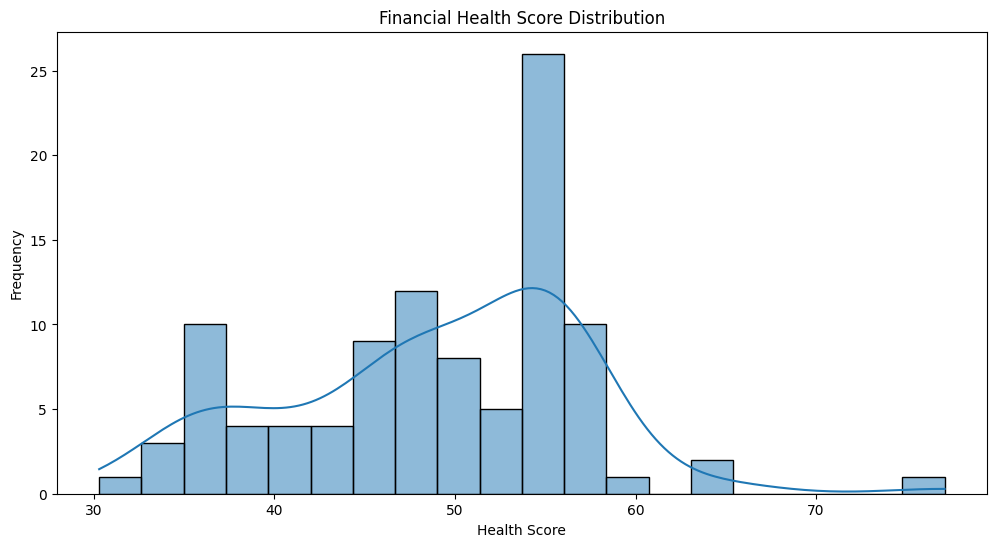

In [32]:
plt.figure(figsize=(12,6))

sns.histplot(
    master_df["financial_health_score"],
    bins=20,
    kde=True
)

plt.title("Financial Health Score Distribution")

plt.xlabel("Health Score")

plt.ylabel("Frequency")

plt.show()